# Imports and functions

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from scipy.stats import ks_2samp

In [2]:
def load_and_filter_data(sim_dir, scenarios, rain_filter_threshold, shift_threshold):
    """
    Load and filter data for selected urbanization scenarios.
    
    Parameters:
    sim_dir (str): Directory containing pickle files
    scenarios (list): List of scenario labels to analyze
    rain_filter_threshold (float): Threshold for filtering rain events
    shift_threshold (int): Threshold for shift range calculation
    
    Returns:
    dict: Dictionary containing historical and future data for each scenario
    """
    data_dict = {}
    
    # Define all available scenarios

    all_scenarios = [
    # Historical rain with urbanization
    ('rain_shift_results_control.pkl', '38% urbanization'),
    ('rain_shift_results_1_1_urbanization_historical_rain.pkl', '42% urbanization'),
    ('rain_shift_results_1_2_urbanization_historical_rain.pkl', '46% urbanization'),
    ('rain_shift_results_1_3_urbanization_historical_rain.pkl', '49% urbanization'),
    ('rain_shift_results_1_4_urbanization_historical_rain.pkl', '53% urbanization'),
    ('rain_shift_results_1_5_urbanization_historical_rain.pkl', '57% urbanization'),
    ('rain_shift_results_2_0_urbanization_historical_rain.pkl', '73% urbanization'),
    ('rain_shift_results_3_0_urbanization_historical_rain.pkl', '81% urbanization'),
    ('rain_shift_results_5_0_urbanization_historical_rain.pkl', '87% urbanization'),
        
    # Climate Change with urbanization       
    ('rain_shift_results_1_0_urbanization.pkl', 'Climate Change 38% urbanization'),
    ('rain_shift_results_1_1_urbanization.pkl', 'Climate Change 42% urbanization'),
    ('rain_shift_results_1_2_urbanization.pkl', 'Climate Change 46% urbanization'),
    ('rain_shift_results_1_3_urbanization.pkl', 'Climate Change 49% urbanization'),
    ('rain_shift_results_1_4_urbanization.pkl', 'Climate Change 53% urbanization'),
    ('rain_shift_results_1_5_urbanization.pkl', 'Climate Change 57% urbanization'),
    ('rain_shift_results_2_0_urbanization.pkl', 'Climate Change 73% urbanization'),
    ('rain_shift_results_3_0_urbanization.pkl', 'Climate Change 81% urbanization'),
    ('rain_shift_results_5_0_urbanization.pkl', 'Climate Change 87% urbanization'),
        
    ]

    # Filter scenarios based on user selection
    selected_scenarios = [(pkl, label) for pkl, label in all_scenarios if label in scenarios]
    
    for pickle_file, label_name in selected_scenarios:
        pickle_file_path = os.path.join(sim_dir, pickle_file)
        
        # Load and filter data
        final_results_df = pd.read_pickle(pickle_file_path)
        filtered_df, _, _ = filter_events_by_rainfall(
            final_results_df, 
            rain_filter_threshold, 
            shift_threshold
        )
        
        # Extract historical and future values
        data_dict[label_name] = {
            'historical': filtered_df[historical_column].values,
            'future': filtered_df[future_column].values
        }
        
    return data_dict

In [3]:
def filter_events_by_rainfall(final_results_df, rain_filter_threshold, shift_threshold):
    """
    Filter out events with total rainfall below threshold and shifts beyond threshold.
    """
    event_nums_to_filter_out = []
    
    for event in final_results_df['event_num'].unique():
        event_df = final_results_df[final_results_df['event_num'] == event]
        
        # Check rain threshold
        rain_condition = (
            (event_df[('historical', 'full_basin', 'total_rain')] < rain_filter_threshold).all() and 
            (event_df[('future', 'full_basin', 'total_rain')] < rain_filter_threshold).all()
        )
        
        # Check shift threshold
        historical_discharge = event_df[('historical', 'basin discharge', 'max_discharge')].values
        future_discharge = event_df[('future', 'basin discharge', 'max_discharge')].values
        shift_condition = abs(future_discharge - historical_discharge) > shift_threshold
        
        if rain_condition or shift_condition.any():
            event_nums_to_filter_out.append(event)
    
    filtered_df = final_results_df[~final_results_df['event_num'].isin(event_nums_to_filter_out)]
    y_shift_range = np.arange(-shift_threshold, shift_threshold + 1, 500)
    filtered_df = filtered_df[filtered_df[('y', '', '')].isin(y_shift_range)]
    num_classes = 2
    print(f'number of events that filtered out: {len(event_nums_to_filter_out)}')
    return filtered_df, y_shift_range, num_classes

In [4]:
def ks_test_for_scenario(data_dict, scenario):
    """
    Perform the Two-sample Kolmogorov-Smirnov test between future and historical data for a given scenario.
    
    Parameters:
    - data_dict (dict): Dictionary containing 'historical' and 'future' data for each scenario.
    - scenario (str): The label of the scenario to analyze (e.g., '39% urbanization').
    
    Returns:
    None: Prints the KS statistic and p-value along with an interpretation.
    """
    if scenario not in data_dict:
        print(f"Error: Scenario '{scenario}' not found in data_dict.")
        return
    
    # Extract future and historical data
    future_data = data_dict[scenario]['future']
    historical_data = data_dict[scenario]['historical']
    
    # Perform KS test
    ks_stat, p_value = ks_2samp(future_data, historical_data)
    
    # Print results
    print(f"KS Test Between Future and Historical Data ({scenario}):")
    print(f"KS Statistic: {ks_stat:.4f}")
    print(f"P-value: {p_value:.4f}")
    
    # Interpretation
    if p_value < 0.05:
        print("The distributions are significantly different.")
    else:
        print("No significant difference between the distributions.")


## MultiIndex([( 'event_num',                       '',                      ''),
            (         'x',                       '',                      ''),
            (         'y',                       '',                      ''),
            (         'd',                       '',                      ''),
            ('historical',        'basin discharge',       'total_discharge'),
            ('historical',        'basin discharge',         'max_discharge'),
            ('historical',        'basin discharge', 'swmm_max_outflow_time'),
            ('historical',        'basin discharge',    'runoff_coefficient'),
            ('historical',             'full_basin',   'max_10min_intensity'),
            ('historical',             'full_basin',   'max_20min_intensity'),
            ('historical',             'full_basin',   'max_30min_intensity'),
            ('historical',             'full_basin',   'max_60min_intensity'),
            ('historical',             'full_basin',  'max_120min_intensity'),
            ('historical',             'full_basin',  'max_240min_intensity'),
            ('historical',             'full_basin',  'max_360min_intensity'),
            ('historical',             'full_basin',  'max_720min_intensity'),
            ('historical',             'full_basin', 'max_1440min_intensity'),
            ('historical',             'full_basin',            'total_rain'),
            ('historical',            'before_peak',   'max_10min_intensity'),
            ('historical',            'before_peak',   'max_20min_intensity'),
            ('historical',            'before_peak',   'max_30min_intensity'),
            ('historical',            'before_peak',   'max_60min_intensity'),
            ('historical',            'before_peak',  'max_120min_intensity'),
            ('historical',            'before_peak',  'max_240min_intensity'),
            ('historical',            'before_peak',  'max_360min_intensity'),
            ('historical',            'before_peak',  'max_720min_intensity'),
            ('historical',            'before_peak', 'max_1440min_intensity'),
            ('historical',            'before_peak',            'total_rain'),
            ('historical',  'singular_subcatchment',   'max_10min_intensity'),
            ('historical',  'singular_subcatchment',   'max_20min_intensity'),
            ('historical',  'singular_subcatchment',   'max_30min_intensity'),
            ('historical',  'singular_subcatchment',   'max_60min_intensity'),
            ('historical',  'singular_subcatchment',  'max_120min_intensity'),
            ('historical',  'singular_subcatchment',  'max_240min_intensity'),
            ('historical',  'singular_subcatchment',  'max_360min_intensity'),
            ('historical',  'singular_subcatchment',  'max_720min_intensity'),
            ('historical',  'singular_subcatchment', 'max_1440min_intensity'),
            ('historical',  'singular_subcatchment',            'total_rain'),
            ('historical', 'Max_Specific_Discharge',         'max_discharge'),
            ('historical', 'Max_Specific_Discharge',       'total_discharge'),
            ('historical', 'Max_Specific_Discharge',    'runoff_coefficient'),
            ('historical', 'Min_Specific_Discharge',         'max_discharge'),
            ('historical', 'Min_Specific_Discharge',       'total_discharge'),
            ('historical', 'Min_Specific_Discharge',    'runoff_coefficient'),
            ('historical',         'Most_Urban_S27',         'max_discharge'),
            ('historical',         'Most_Urban_S27',       'total_discharge'),
            ('historical',         'Most_Urban_S27',    'runoff_coefficient'),
            ('historical',        'Least_Urban_S28',         'max_discharge'),
            ('historical',        'Least_Urban_S28',       'total_discharge'),
            ('historical',        'Least_Urban_S28',    'runoff_coefficient'),
            (    'future',        'basin discharge',       'total_discharge'),
            (    'future',        'basin discharge',         'max_discharge'),
            (    'future',        'basin discharge', 'swmm_max_outflow_time'),
            (    'future',        'basin discharge',    'runoff_coefficient'),
            (    'future',             'full_basin',   'max_10min_intensity'),
            (    'future',             'full_basin',   'max_20min_intensity'),
            (    'future',             'full_basin',   'max_30min_intensity'),
            (    'future',             'full_basin',   'max_60min_intensity'),
            (    'future',             'full_basin',  'max_120min_intensity'),
            (    'future',             'full_basin',  'max_240min_intensity'),
            (    'future',             'full_basin',  'max_360min_intensity'),
            (    'future',             'full_basin',  'max_720min_intensity'),
            (    'future',             'full_basin', 'max_1440min_intensity'),
            (    'future',             'full_basin',            'total_rain'),
            (    'future',            'before_peak',   'max_10min_intensity'),
            (    'future',            'before_peak',   'max_20min_intensity'),
            (    'future',            'before_peak',   'max_30min_intensity'),
            (    'future',            'before_peak',   'max_60min_intensity'),
            (    'future',            'before_peak',  'max_120min_intensity'),
            (    'future',            'before_peak',  'max_240min_intensity'),
            (    'future',            'before_peak',  'max_360min_intensity'),
            (    'future',            'before_peak',  'max_720min_intensity'),
            (    'future',            'before_peak', 'max_1440min_intensity'),
            (    'future',            'before_peak',            'total_rain'),
            (    'future',  'singular_subcatchment',   'max_10min_intensity'),
            (    'future',  'singular_subcatchment',   'max_20min_intensity'),
            (    'future',  'singular_subcatchment',   'max_30min_intensity'),
            (    'future',  'singular_subcatchment',   'max_60min_intensity'),
            (    'future',  'singular_subcatchment',  'max_120min_intensity'),
            (    'future',  'singular_subcatchment',  'max_240min_intensity'),
            (    'future',  'singular_subcatchment',  'max_360min_intensity'),
            (    'future',  'singular_subcatchment',  'max_720min_intensity'),
            (    'future',  'singular_subcatchment', 'max_1440min_intensity'),
            (    'future',  'singular_subcatchment',            'total_rain'),
            (    'future', 'Max_Specific_Discharge',         'max_discharge'),
            (    'future', 'Max_Specific_Discharge',       'total_discharge'),
            (    'future', 'Max_Specific_Discharge',    'runoff_coefficient'),
            (    'future', 'Min_Specific_Discharge',         'max_discharge'),
            (    'future', 'Min_Specific_Discharge',       'total_discharge'),
            (    'future', 'Min_Specific_Discharge',    'runoff_coefficient'),
            (    'future',         'Most_Urban_S27',         'max_discharge'),
            (    'future',         'Most_Urban_S27',       'total_discharge'),
            (    'future',         'Most_Urban_S27',    'runoff_coefficient'),
            (    'future',        'Least_Urban_S28',         'max_discharge'),
            (    'future',        'Least_Urban_S28',       'total_discharge'),
            (    'future',        'Least_Urban_S28',    'runoff_coefficient')],
           )

### Select scenarios from here:

    all_scenarios = [
    # Historical rain with urbanization
    ('rain_shift_results_control.pkl', 'Control'),
    ('rain_shift_results_1_1_urbanization_historical_rain.pkl', '42% urbanization'),
    ('rain_shift_results_1_2_urbanization_historical_rain.pkl', '46% urbanization'),
    ('rain_shift_results_1_3_urbanization_historical_rain.pkl', '49% urbanization'),
    ('rain_shift_results_1_4_urbanization_historical_rain.pkl', '53% urbanization'),
    ('rain_shift_results_1_5_urbanization_historical_rain.pkl', '57% urbanization'),
    ('rain_shift_results_2_0_urbanization_historical_rain.pkl', '73% urbanization'),
    ('rain_shift_results_3_0_urbanization_historical_rain.pkl', '81% urbanization'),
    ('rain_shift_results_5_0_urbanization_historical_rain.pkl', '87% urbanization'),
        
    # Climate Change with urbanization       
    ('rain_shift_results_1_0_urbanization.pkl', 'Climate Change 39% urbanization'),
    ('rain_shift_results_1_1_urbanization.pkl', 'Climate Change 42% urbanization'),
    ('rain_shift_results_1_2_urbanization.pkl', 'Climate Change 46% urbanization'),
    ('rain_shift_results_1_3_urbanization.pkl', 'Climate Change 49% urbanization'),
    ('rain_shift_results_1_4_urbanization.pkl', 'Climate Change 53% urbanization'),
    ('rain_shift_results_1_5_urbanization.pkl', 'Climate Change 57% urbanization'),
    ('rain_shift_results_2_0_urbanization.pkl', 'Climate Change 73% urbanization'),
    ('rain_shift_results_3_0_urbanization.pkl', 'Climate Change 81% urbanization'),
    ('rain_shift_results_5_0_urbanization.pkl', 'Climate Change 87% urbanization'),
        
    ]


In [5]:
# Configuration
sim_dir = r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change\pickles"
rain_filter_threshold = 10  # mm
shift_threshold = 20000     # meters

# Define columns for analysis
historical_column = ('historical', 'basin discharge', 'max_discharge')
future_column = ('future', 'basin discharge', 'max_discharge')


# historical_column = (    'historical',             'full_basin',   'max_10min_intensity')
# future_column = (    'future',             'full_basin',   'max_10min_intensity')


# Select scenarios to compare
selected_scenarios = [
    '38% urbanization',
    '42% urbanization',
    '49% urbanization',
#     '53% urbanization',
    '57% urbanization',
    '73% urbanization',
    '81% urbanization',
    '87% urbanization',
    
    'Climate Change 38% urbanization',
    'Climate Change 42% urbanization',
    'Climate Change 49% urbanization',
#     'Climate Change 53% urbanization',    
    'Climate Change 57% urbanization',   
    'Climate Change 73% urbanization',
    'Climate Change 81% urbanization',
    'Climate Change 87% urbanization',
]

# Load and process data
data_dict = load_and_filter_data(sim_dir, selected_scenarios, 
                               rain_filter_threshold, shift_threshold)

# Create plot titles
dynamic_title = f"{historical_column[1].replace('_', ' ').title()} - {historical_column[2].replace('_', ' ').title()}"
x_label = f"{historical_column[2].replace('_', ' ').title()}"


# Set global font sizes
plt.rc('font', size=14)          # Default text size
plt.rc('axes', titlesize=18)     # Title font size
plt.rc('axes', labelsize=16)     # Axes labels font size
plt.rc('legend', fontsize=14)    # Legend font size
plt.rc('xtick', labelsize=12)    # X-axis tick font size
plt.rc('ytick', labelsize=12)    # Y-axis tick font size

number of events that filtered out: 8
number of events that filtered out: 8
number of events that filtered out: 8
number of events that filtered out: 8
number of events that filtered out: 8
number of events that filtered out: 8
number of events that filtered out: 8
number of events that filtered out: 8
number of events that filtered out: 8
number of events that filtered out: 8
number of events that filtered out: 8
number of events that filtered out: 8
number of events that filtered out: 8
number of events that filtered out: 8


# Bootstrap

In [6]:
def bootstrap_percentile(data, percentile, n_iterations=10000):
    """
    Perform Bootstrap analysis to compute the distribution of a specific percentile,
    and print the number of bootstrap samples above the threshold.

    Parameters:
    - data (array-like): Original dataset to sample from.
    - percentile (float): Percentile to compute (e.g., 95 for 95th percentile).
    - n_iterations (int): Number of bootstrap iterations.

    Returns:
    - percentiles (list): List of bootstrap estimates for the specified percentile.
    """
    percentiles = []

    # Calculate the threshold from the original data
    threshold = np.percentile(data, percentile)

    for _ in range(n_iterations):
        # Sample with replacement from the data
        sampled_data = np.random.choice(data, size=len(data), replace=True)
        
        # Compute the specified percentile
        percentile_value = np.percentile(sampled_data, percentile)
        percentiles.append(percentile_value)

    # Count how many bootstrap samples are above the threshold
    count_above_threshold = sum(np.array(percentiles) > threshold)
    
    # Print the result
    print(f"Number of bootstrap samples above the {percentile}th percentile threshold ({threshold:.2f}):")
    print(f"  Above Threshold: {count_above_threshold}/{n_iterations}")

    return percentiles

In [36]:
# Define the scenarios and percentile to analyze
urbanization_levels = [    '39% urbanization',
#     '42% urbanization',
#     '49% urbanization',
#     '53% urbanization',
    '57% urbanization',
#     '73% urbanization',
    '81% urbanization',]
percentile_to_analyze = 90  # For example, the 90th percentile

# Store results for each scenario
results = {}

In [37]:
for urbanization_level in urbanization_levels:
    print(f"\nAnalyzing scenario: {urbanization_level}")

    # Perform bootstrap analysis for No Climate Change
    no_climate_data = data_dict[urbanization_level]['future']
    no_climate_percentiles = bootstrap_percentile(no_climate_data, percentile_to_analyze, n_iterations=10000)

    # Perform bootstrap analysis for Climate Change
    climate_change_data = data_dict[f"Climate Change {urbanization_level}"]['future']
    climate_change_percentiles = bootstrap_percentile(climate_change_data, percentile_to_analyze, n_iterations=10000)

    # Perform Kolmogorov-Smirnov test
    ks_stat, p_value = ks_2samp(no_climate_percentiles, climate_change_percentiles)

    # Store results
    results[urbanization_level] = {
        'no_climate_percentiles': no_climate_percentiles,
        'climate_change_percentiles': climate_change_percentiles,
        'ks_stat': ks_stat,
        'p_value': p_value
    }

    # Print KS test results
#     print("\nKolmogorov-Smirnov Test Results:")
#     print(f"  KS Statistic: {ks_stat:.4f}")
#     print(f"  P-value: {p_value:.4f}")

    # Interpretation of the KS test
    if p_value < 0.05:
        print("The distributions are significantly different (p < 0.05).")
    else:
        print("No significant difference between the distributions (p >= 0.05).")

    # Print mean and confidence intervals for both distributions
    no_climate_mean = np.mean(no_climate_percentiles)
    climate_change_mean = np.mean(climate_change_percentiles)
    no_climate_ci = np.percentile(no_climate_percentiles, [2.5, 97.5])
    climate_change_ci = np.percentile(climate_change_percentiles, [2.5, 97.5])

#     print(f"\n{percentile_to_analyze}th Percentile (No Climate Change): Mean = {no_climate_mean:.2f}, CI = {no_climate_ci}")
#     print(f"{percentile_to_analyze}th Percentile (Climate Change): Mean = {climate_change_mean:.2f}, CI = {climate_change_ci}")


Analyzing scenario: 39% urbanization
Number of bootstrap samples above the 90th percentile threshold (20.82):
  Above Threshold: 4902/10000
Number of bootstrap samples above the 90th percentile threshold (24.22):
  Above Threshold: 4954/10000
The distributions are significantly different (p < 0.05).

Analyzing scenario: 57% urbanization
Number of bootstrap samples above the 90th percentile threshold (31.89):
  Above Threshold: 4901/10000
Number of bootstrap samples above the 90th percentile threshold (35.19):
  Above Threshold: 4944/10000
The distributions are significantly different (p < 0.05).

Analyzing scenario: 81% urbanization
Number of bootstrap samples above the 90th percentile threshold (44.10):
  Above Threshold: 4979/10000
Number of bootstrap samples above the 90th percentile threshold (45.97):
  Above Threshold: 4880/10000
The distributions are significantly different (p < 0.05).


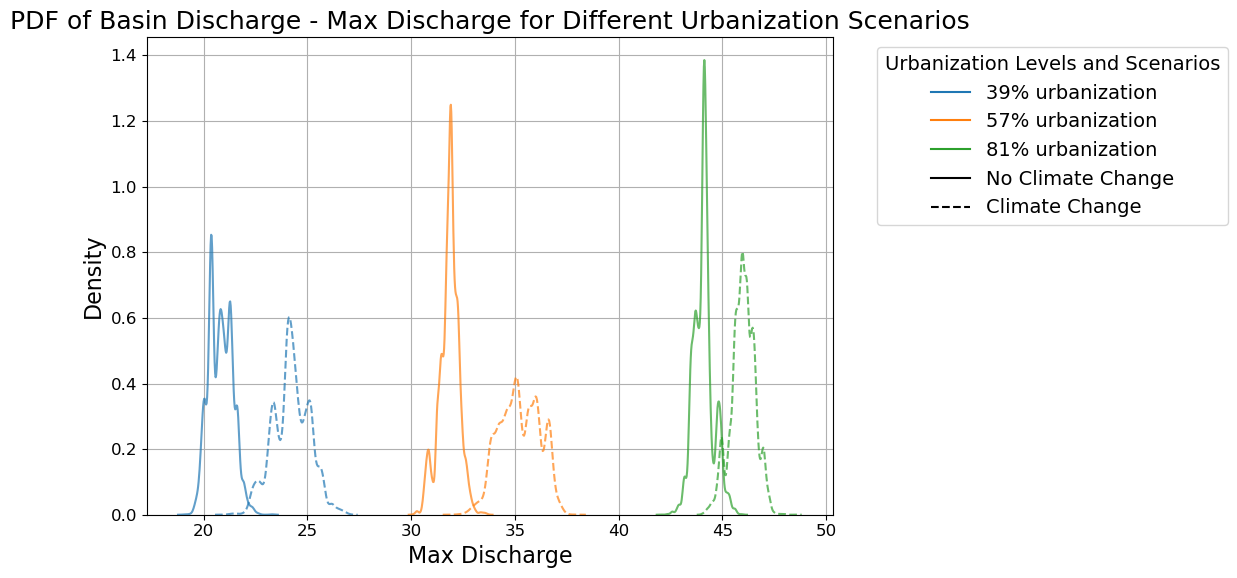

In [38]:
# PDF Visualization
plt.figure(figsize=(12, 6))
colors = sns.color_palette("tab10", n_colors=12)  # Define colors for urbanization scenarios
for idx, urbanization_level in enumerate(urbanization_levels):
    sns.kdeplot(results[urbanization_level]['no_climate_percentiles'], 
                label=f"{urbanization_level}",  # Each urbanization level is labeled once
                linestyle='-', color=colors[idx], alpha=0.7)
    sns.kdeplot(results[urbanization_level]['climate_change_percentiles'], 
                linestyle='--', color=colors[idx], alpha=0.7)

# Add legend with simplified explanation
solid_line = plt.Line2D([0], [0], color='black', linestyle='-', label="No Climate Change")
dashed_line = plt.Line2D([0], [0], color='black', linestyle='--', label="Climate Change")
handles = [plt.Line2D([0], [0], color=colors[i], label=f"{urbanization_levels[i]}") for i in range(len(urbanization_levels))]
handles.extend([solid_line, dashed_line])

plt.legend(handles=handles, title="Urbanization Levels and Scenarios", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title(f"PDF of {dynamic_title} for Different Urbanization Scenarios")
plt.xlabel(x_label)
plt.ylabel("Density")
plt.grid(True)
plt.tight_layout()
plt.show()

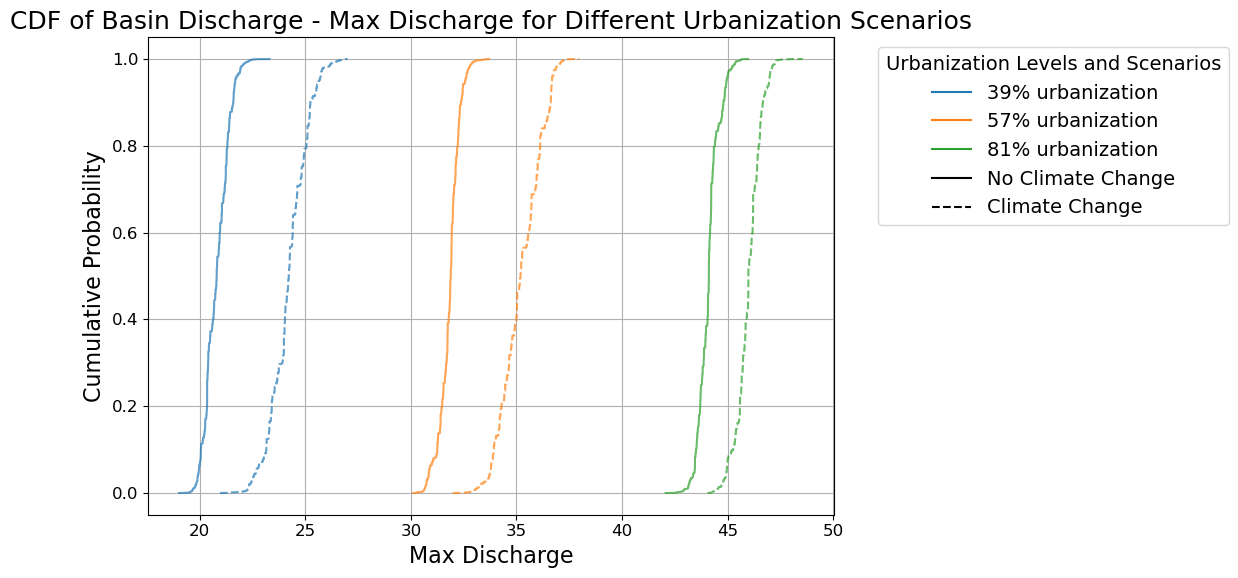

In [39]:
# CDF Visualization
plt.figure(figsize=(12, 6))
for idx, urbanization_level in enumerate(urbanization_levels):
    # Compute sorted data and cumulative probability
    no_climate_sorted = np.sort(results[urbanization_level]['no_climate_percentiles'])
    climate_change_sorted = np.sort(results[urbanization_level]['climate_change_percentiles'])
    cdf_no_climate = np.arange(1, len(no_climate_sorted) + 1) / len(no_climate_sorted)
    cdf_climate_change = np.arange(1, len(climate_change_sorted) + 1) / len(climate_change_sorted)
    
    # Plot CDFs
    plt.plot(no_climate_sorted, cdf_no_climate, label=f"{urbanization_level}", 
             linestyle='-', color=colors[idx], alpha=0.7)
    plt.plot(climate_change_sorted, cdf_climate_change, 
             linestyle='--', color=colors[idx], alpha=0.7)

# Add legend with simplified explanation
plt.legend(handles=handles, title="Urbanization Levels and Scenarios", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title(f"CDF of {dynamic_title} for Different Urbanization Scenarios")
plt.xlabel(x_label)
plt.ylabel("Cumulative Probability")
plt.grid(True)
plt.tight_layout()
plt.show()

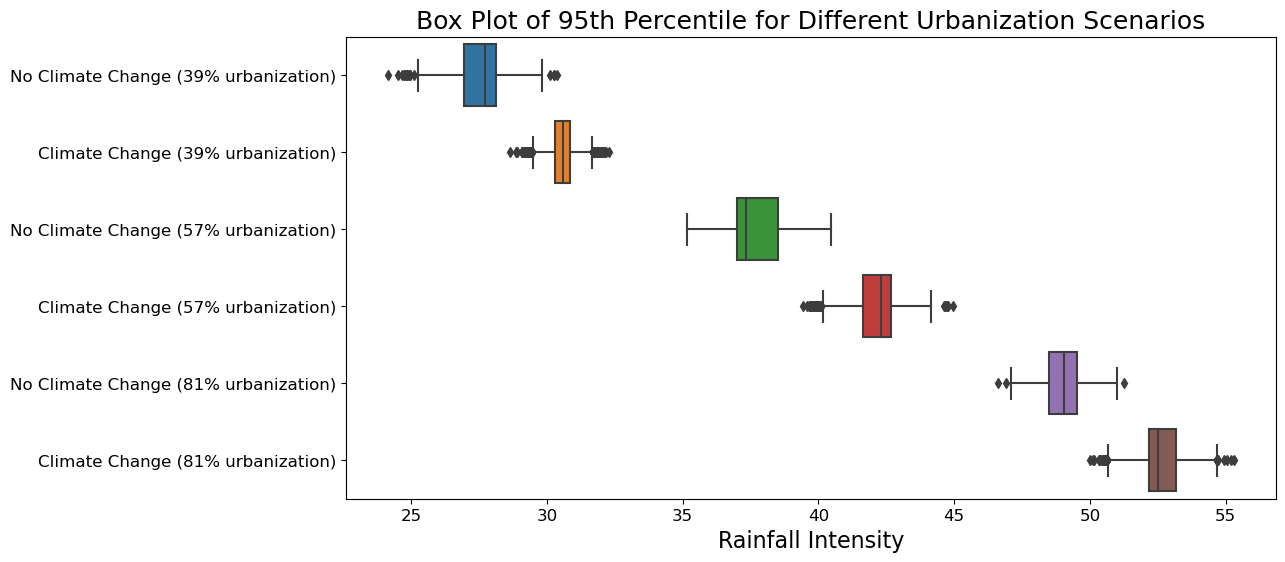

In [34]:
# Box Plot Visualization
plt.figure(figsize=(12, 6))
all_data = []
all_labels = []
for urbanization_level in urbanization_levels:
    all_data.append(results[urbanization_level]['no_climate_percentiles'])
    all_labels.append(f"No Climate Change ({urbanization_level})")
    all_data.append(results[urbanization_level]['climate_change_percentiles'])
    all_labels.append(f"Climate Change ({urbanization_level})")

sns.boxplot(data=all_data, orient='h')
plt.yticks(ticks=range(len(all_labels)), labels=all_labels)
plt.title(f"Box Plot of {percentile_to_analyze}th Percentile for Different Urbanization Scenarios")
plt.xlabel("Rainfall Intensity")
plt.show()

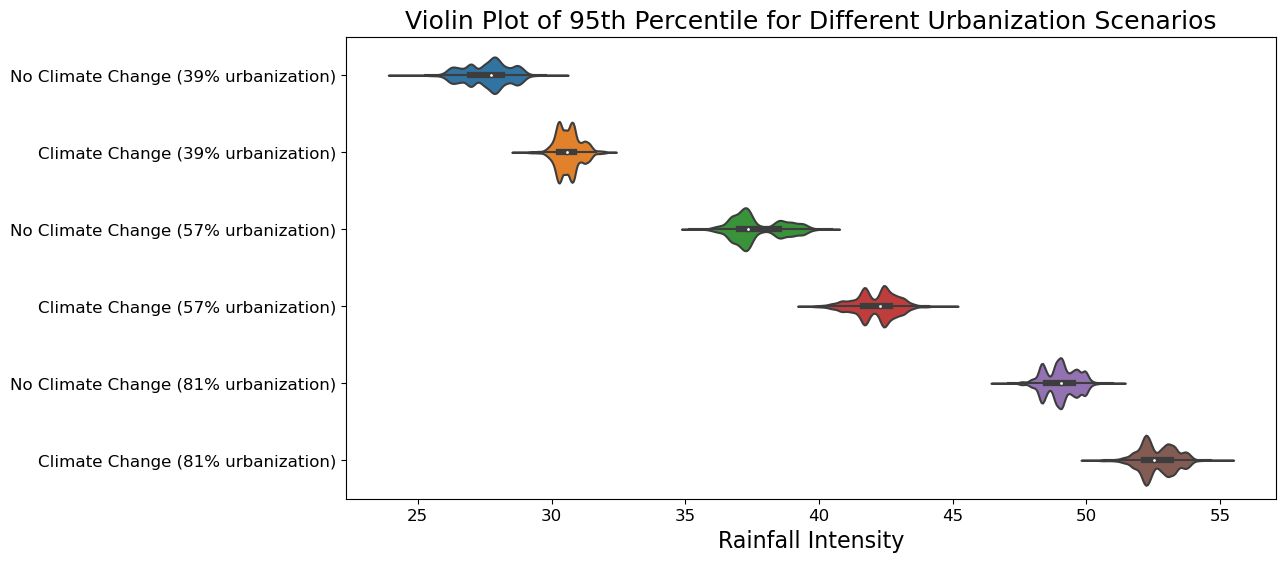

In [35]:
# Violin Plot Visualization
plt.figure(figsize=(12, 6))
sns.violinplot(data=all_data, orient='h')
plt.yticks(ticks=range(len(all_labels)), labels=all_labels)
plt.title(f"Violin Plot of {percentile_to_analyze}th Percentile for Different Urbanization Scenarios")
plt.xlabel("Rainfall Intensity")
plt.show()